In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [4]:
os.makedirs('artifacts/figures', exist_ok=True)

In [5]:
dataset_name = "EMNIST"

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.EMNIST(
    root="./data",
    split="balanced",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.EMNIST(
    root="./data",
    split="balanced",
    train=False,
    download=True,
    transform=transform
)

100.0%


In [6]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

generator = torch.Generator().manual_seed(seed)

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=generator
)

In [7]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [8]:
x, y = next(iter(train_loader))

print('batch size:', batch_size)
print('x shape:', x.shape)
print('y shape:', y.shape)
print('value range:', x.min(), x.max())

batch size: 128
x shape: torch.Size([128, 1, 28, 28])
y shape: torch.Size([128])
value range: tensor(0.) tensor(1.)


In [9]:
class MLP(nn.Module):

    def __init__(self, hidden=[256,128], dropout=0.0, batchnorm=False):
        super().__init__()

        layers = []
        input_dim = 28*28

        for h in hidden:

            layers.append(nn.Linear(input_dim, h))

            if batchnorm:
                layers.append(nn.BatchNorm1d(h))

            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            input_dim = h

        layers.append(nn.Linear(input_dim, 47))

        self.net = nn.Sequential(
            nn.Flatten(),
            *layers
        )

    def forward(self, x):
        return self.net(x)


def accuracy(logits, targets):

    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    total_loss = 0
    total_acc = 0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(logits, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy(logits, y)

    return total_loss / len(loader), total_acc / len(loader)


def evaluate(model, loader, criterion):

    model.eval()

    total_loss = 0
    total_acc = 0

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            logits = model(x)

            loss = criterion(logits, y)

            total_loss += loss.item()
            total_acc += accuracy(logits, y)

    return total_loss / len(loader), total_acc / len(loader)


class EarlyStopping:

    def __init__(self, patience=4, path="artifacts/best_model.pt"):

        self.patience = patience
        self.counter = 0
        self.best_score = None
        self.path = path
        self.stop = False

    def step(self, score, model):

        if self.best_score is None or score > self.best_score:

            self.best_score = score
            self.counter = 0

            torch.save(model.state_dict(), self.path)

        else:

            self.counter += 1

            if self.counter >= self.patience:
                self.stop = True


def train_model(model, optimizer, epochs, early_stopping=None):

    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} "
            f"train_loss={train_loss:.3f} "
            f"val_loss={val_loss:.3f} "
            f"val_acc={val_acc:.3f}"
        )

        if early_stopping:

            early_stopping.step(val_acc, model)

            if early_stopping.stop:
                print("Early stopping triggered")
                break

    if early_stopping:
        model.load_state_dict(torch.load(early_stopping.path))

    return history

In [10]:
runs = []

# ---------- E1 ----------

print("\nE1: Base model")

model = MLP(hidden=[256,128]).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

history_E1 = train_model(model, optimizer, epochs=15)

runs.append([
"E1",dataset_name,seed,"256-128/ReLU",
"Adam",1e-3,0,0,
len(history_E1["val_acc"]),
max(history_E1["val_acc"]),
min(history_E1["val_loss"])
])

# ---------- E2 ----------

print("\nE2: Dropout")

model = MLP(hidden=[256,128], dropout=0.3).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

history_E2 = train_model(model, optimizer, epochs=15)

runs.append([
"E2",dataset_name,seed,"256-128/ReLU/dropout",
"Adam",1e-3,0,0,
len(history_E2["val_acc"]),
max(history_E2["val_acc"]),
min(history_E2["val_loss"])
])

# ---------- E3 ----------

print("\nE3: BatchNorm")

model = MLP(hidden=[256,128], batchnorm=True).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

history_E3 = train_model(model, optimizer, epochs=15)

runs.append([
"E3",dataset_name,seed,"256-128/ReLU/batchnorm",
"Adam",1e-3,0,0,
len(history_E3["val_acc"]),
max(history_E3["val_acc"]),
min(history_E3["val_loss"])
])




E1: Base model
Epoch 1/15 train_loss=1.291 val_loss=0.830 val_acc=0.751
Epoch 2/15 train_loss=0.701 val_loss=0.657 val_acc=0.796
Epoch 3/15 train_loss=0.570 val_loss=0.582 val_acc=0.814
Epoch 4/15 train_loss=0.500 val_loss=0.540 val_acc=0.825
Epoch 5/15 train_loss=0.455 val_loss=0.519 val_acc=0.833
Epoch 6/15 train_loss=0.419 val_loss=0.498 val_acc=0.841
Epoch 7/15 train_loss=0.390 val_loss=0.496 val_acc=0.836
Epoch 8/15 train_loss=0.370 val_loss=0.499 val_acc=0.840
Epoch 9/15 train_loss=0.345 val_loss=0.494 val_acc=0.844
Epoch 10/15 train_loss=0.329 val_loss=0.503 val_acc=0.839
Epoch 11/15 train_loss=0.312 val_loss=0.503 val_acc=0.839
Epoch 12/15 train_loss=0.297 val_loss=0.505 val_acc=0.840
Epoch 13/15 train_loss=0.282 val_loss=0.505 val_acc=0.841
Epoch 14/15 train_loss=0.269 val_loss=0.512 val_acc=0.843
Epoch 15/15 train_loss=0.257 val_loss=0.529 val_acc=0.837

E2: Dropout
Epoch 1/15 train_loss=1.556 val_loss=0.859 val_acc=0.740
Epoch 2/15 train_loss=0.940 val_loss=0.683 val_acc=0.

In [11]:
acc_E2 = max(history_E2["val_acc"])
acc_E3 = max(history_E3["val_acc"])

use_dropout = acc_E2 >= acc_E3
use_batchnorm = acc_E3 > acc_E2

print("\nBest regularization:",
      "Dropout" if use_dropout else "BatchNorm")

# ---------- E4 ----------

print("\nE4: EarlyStopping")

model = MLP(
    hidden=[256,128],
    dropout=0.3 if use_dropout else 0,
    batchnorm=use_batchnorm
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

early_stopping = EarlyStopping(patience=4)

history_E4 = train_model(
    model,
    optimizer,
    epochs=15,
    early_stopping=early_stopping
)

runs.append([
"E4",dataset_name,seed,f"256-128/{'dropout' if use_dropout else 'batchnorm'}",
"Adam",1e-3,0,0,
len(history_E4["val_acc"]),
max(history_E4["val_acc"]),
min(history_E4["val_loss"])
])



Best regularization: BatchNorm

E4: EarlyStopping
Epoch 1/15 train_loss=0.993 val_loss=0.589 val_acc=0.812
Epoch 2/15 train_loss=0.529 val_loss=0.532 val_acc=0.827
Epoch 3/15 train_loss=0.449 val_loss=0.491 val_acc=0.837
Epoch 4/15 train_loss=0.401 val_loss=0.480 val_acc=0.845
Epoch 5/15 train_loss=0.367 val_loss=0.470 val_acc=0.842
Epoch 6/15 train_loss=0.341 val_loss=0.456 val_acc=0.848
Epoch 7/15 train_loss=0.322 val_loss=0.456 val_acc=0.849
Epoch 8/15 train_loss=0.301 val_loss=0.461 val_acc=0.848
Epoch 9/15 train_loss=0.287 val_loss=0.473 val_acc=0.847
Epoch 10/15 train_loss=0.271 val_loss=0.470 val_acc=0.846
Epoch 11/15 train_loss=0.261 val_loss=0.478 val_acc=0.846
Early stopping triggered


In [12]:
os.makedirs("artifacts", exist_ok=True)

torch.save(model.state_dict(), "artifacts/best_model.pt")

In [13]:
def plot_experiment_curves(exp_id, history, save_path=None):
    """
    Рисует графики loss и accuracy для одного эксперимента.

    Параметры:
        exp_id (str): ID эксперимента, например "E1"
        history (dict): словарь с ключами "train_loss", "val_loss", "train_acc", "val_acc"
        save_path (str, optional): путь для сохранения картинки, если None - просто показывает
    """
    train_loss = history["train_loss"]
    val_loss = history["val_loss"]
    train_acc = history["train_acc"]
    val_acc = history["val_acc"]

    fig, axes = plt.subplots(2, 1, figsize=(8, 6))

    # График Loss
    axes[0].plot(train_loss, label="Train Loss")
    axes[0].plot(val_loss, '--', label="Validation Loss")
    axes[0].set_title(f"{exp_id} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # График Accuracy
    axes[1].plot(train_acc, label="Train Accuracy")
    axes[1].plot(val_acc, '--', label="Validation Accuracy")
    axes[1].set_title(f"{exp_id} Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

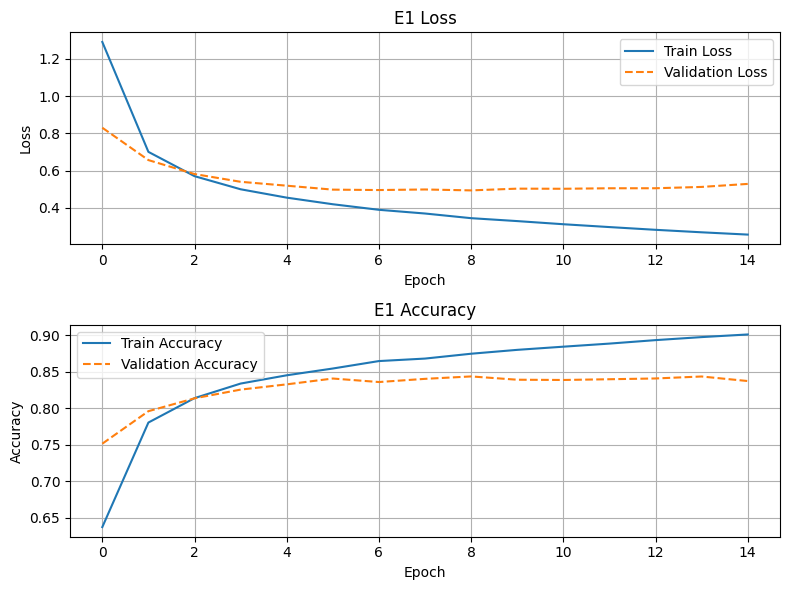

In [14]:
plot_experiment_curves('E1', history_E1)

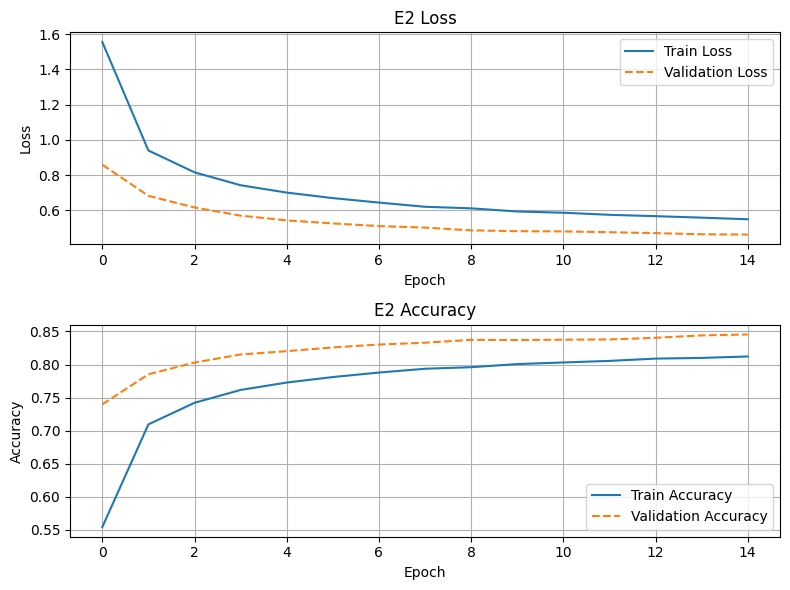

In [15]:
plot_experiment_curves('E2', history_E2)

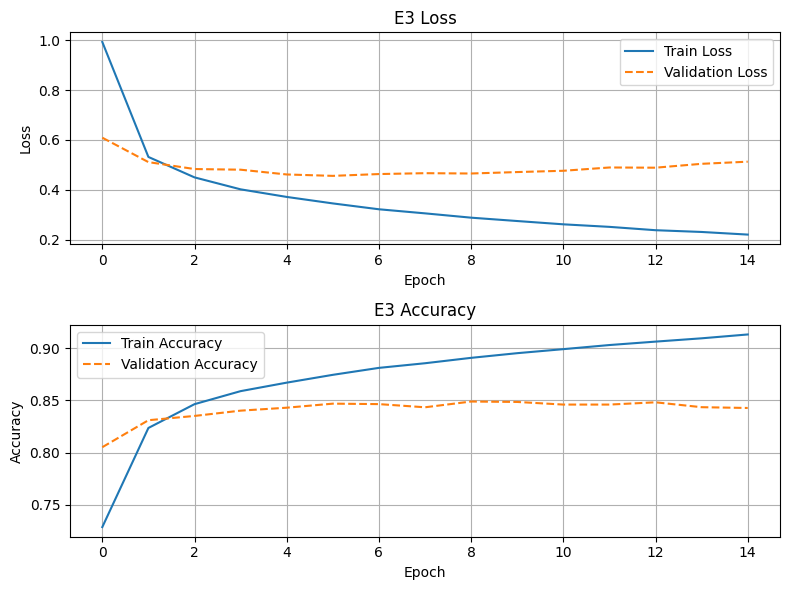

In [16]:
plot_experiment_curves('E3', history_E3)

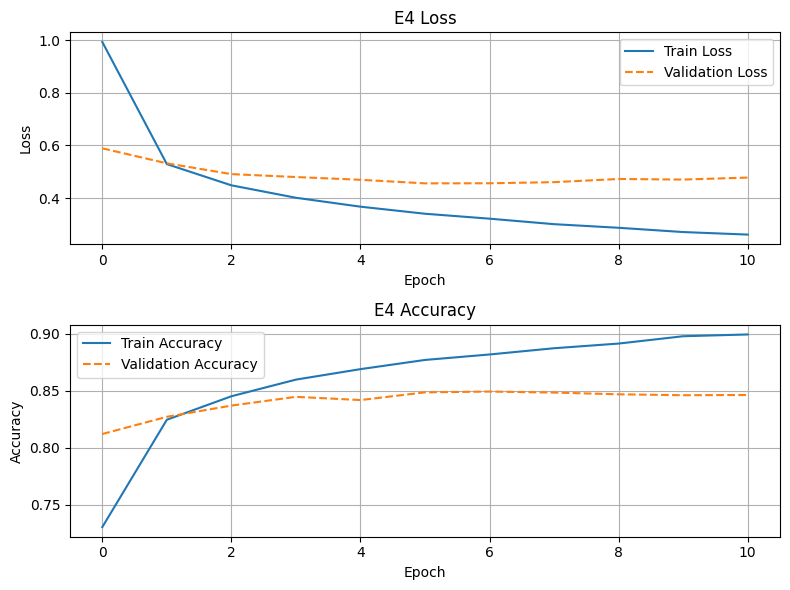

In [17]:
os.makedirs("artifacts/figures", exist_ok=True)
plot_experiment_curves('E4', history_E4, 'artifacts/figures/curves_best.png')

In [18]:
model.load_state_dict(torch.load("artifacts/best_model.pt"))

criterion = nn.CrossEntropyLoss()

test_loss, test_acc = evaluate(model, test_loader, criterion)

print("TEST ACC:", test_acc)

TEST ACC: 0.8427174440046556


In [19]:
print("\nO1: LR too large")

model = MLP(hidden=[256,128], dropout=0.3).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-1)

history_O1 = train_model(model, optimizer, epochs=6)

print("\nO2: LR too small")

model = MLP(hidden=[256,128], dropout=0.3).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-5)

history_O2 = train_model(model, optimizer, epochs=6)

print("\nO3: SGD + momentum")

model = MLP(hidden=[256,128], dropout=0.3).to(device)

optimizer = optim.SGD(
    model.parameters(),
    lr=1e-2,
    momentum=0.9,
    weight_decay=1e-4
)

history_O3 = train_model(model, optimizer, epochs=12)

runs.append([
"O1",dataset_name,seed,"256-128 dropout",
"Adam",1e-1,0,0,
len(history_O1["val_acc"]),
max(history_O1["val_acc"]),
min(history_O1["val_loss"])
])

runs.append([
"O2",dataset_name,seed,"256-128 dropout",
"Adam",1e-5,0,0,
len(history_O2["val_acc"]),
max(history_O2["val_acc"]),
min(history_O2["val_loss"])
])

runs.append([
"O3",dataset_name,seed,"256-128 dropout",
"SGD",1e-2,0.9,1e-4,
len(history_O3["val_acc"]),
max(history_O3["val_acc"]),
min(history_O3["val_loss"])
])


O1: LR too large
Epoch 1/6 train_loss=4.039 val_loss=3.860 val_acc=0.021
Epoch 2/6 train_loss=3.869 val_loss=3.865 val_acc=0.021
Epoch 3/6 train_loss=3.865 val_loss=3.861 val_acc=0.021
Epoch 4/6 train_loss=3.865 val_loss=3.860 val_acc=0.020
Epoch 5/6 train_loss=3.864 val_loss=3.867 val_acc=0.021
Epoch 6/6 train_loss=3.866 val_loss=3.861 val_acc=0.021

O2: LR too small
Epoch 1/6 train_loss=3.812 val_loss=3.736 val_acc=0.093
Epoch 2/6 train_loss=3.625 val_loss=3.450 val_acc=0.194
Epoch 3/6 train_loss=3.323 val_loss=3.090 val_acc=0.317
Epoch 4/6 train_loss=3.025 val_loss=2.769 val_acc=0.394
Epoch 5/6 train_loss=2.784 val_loss=2.513 val_acc=0.440
Epoch 6/6 train_loss=2.588 val_loss=2.313 val_acc=0.470

O3: SGD + momentum
Epoch 1/12 train_loss=2.479 val_loss=1.344 val_acc=0.623
Epoch 2/12 train_loss=1.359 val_loss=0.983 val_acc=0.709
Epoch 3/12 train_loss=1.106 val_loss=0.831 val_acc=0.749
Epoch 4/12 train_loss=0.977 val_loss=0.738 val_acc=0.774
Epoch 5/12 train_loss=0.894 val_loss=0.682 v

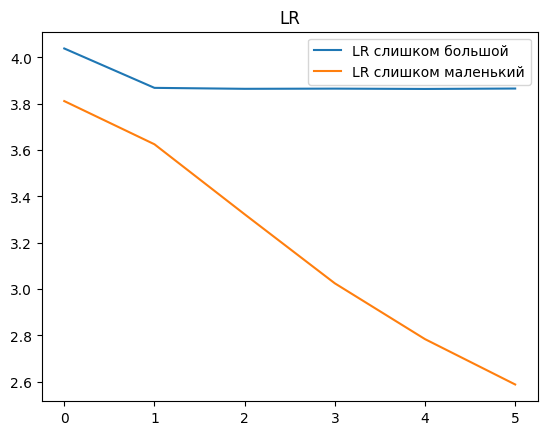

In [20]:
plt.figure()

plt.plot(history_O1["train_loss"], label="LR слишком большой")
plt.plot(history_O2["train_loss"], label="LR слишком маленький")

plt.legend()

plt.title("LR")

plt.savefig("artifacts/figures/curves_lr_extremes.png")

plt.show()

In [21]:
config = {
"dataset": dataset_name,
"seed": seed,
"hidden_layers": [256,128],
"dropout": 0.3 if use_dropout else 0,
"batchnorm": use_batchnorm,
"optimizer": "Adam",
"lr": 1e-3
}

with open("artifacts/best_config.json","w") as f:
    json.dump(config,f,indent=4)

In [22]:
df = pd.DataFrame(
runs,
columns=[
"experiment_id",
"dataset",
"seed",
"model_summary",
"optimizer",
"lr",
"momentum",
"weight_decay",
"epochs_trained",
"best_val_accuracy",
"best_val_loss"
]
)

df.to_csv("artifacts/runs.csv", index=False)

df

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST,42,256-128/ReLU,Adam,0.00100,0.0,0.0000,15,0.843529,0.493827
1,E2,EMNIST,42,256-128/ReLU/dropout,Adam,0.00100,0.0,0.0000,15,0.845516,0.462701
2,E3,EMNIST,42,256-128/ReLU/batchnorm,Adam,0.00100,0.0,0.0000,15,0.848914,0.456027
3,E4,EMNIST,42,256-128/batchnorm,Adam,0.00100,0.0,0.0000,11,0.849179,0.456018
4,O1,EMNIST,42,256-128 dropout,Adam,0.10000,0.0,0.0000,6,0.021319,3.859584
5,O2,EMNIST,42,256-128 dropout,Adam,0.00001,0.0,0.0000,6,0.469633,2.312788
6,O3,EMNIST,42,256-128 dropout,SGD,0.01000,0.9,0.0001,12,0.822873,0.536253


In [23]:
import sys
import torch
import torchvision

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

Python: 3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) [MSC v.1937 64 bit (AMD64)]
Torch: 2.10.0+cpu
Torchvision: 0.25.0+cpu
